# WESAD ECG – Data Understanding

Goal:
- Understand WESAD file structure
- Load chest ECG and labels
- Inspect signal properties
- Verify stress annotations

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neurokit2 as nk
from scipy import signal

plt.rcParams["figure.figsize"] = (15, 4)


In [ ]:
DATASET_PATH = "../../data/WESAD"   # change if needed

subjects = sorted([d for d in os.listdir(DATASET_PATH) if d.startswith("S")])
subjects

['S10',
 'S11',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17',
 'S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9']

In [3]:
import pickle

subject = "S2"
subject_path = os.path.join(DATASET_PATH, subject, f"{subject}.pkl")

with open(subject_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

/tmp/ipykernel_24979/638106032.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


In [4]:
data.keys()

dict_keys(['signal', 'label', 'subject'])

In [5]:
data["signal"].keys()

dict_keys(['chest', 'wrist'])

In [6]:
data["signal"]["chest"].keys()

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

In [7]:
ecg = data["signal"]["chest"]["ECG"].squeeze()
labels = data["label"]

In [8]:
ecg.shape, labels.shape

((4255300,), (4255300,))

In [10]:
FS = 700

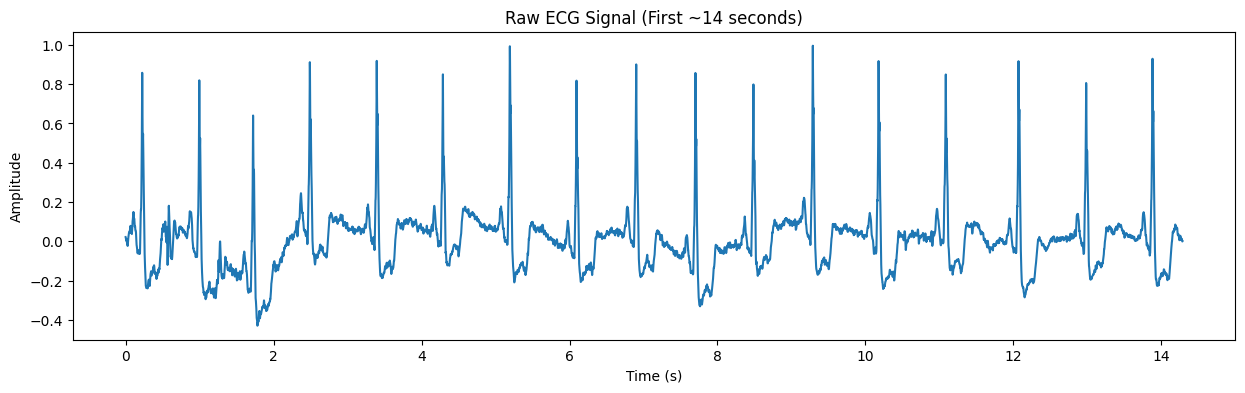

In [11]:
t = np.arange(len(ecg)) / FS

plt.plot(t[:10_000], ecg[:10_000])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw ECG Signal (First ~14 seconds)")
plt.show()

In [12]:
unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique, counts))


{np.int32(0): np.int64(2142701),
 np.int32(1): np.int64(800800),
 np.int32(2): np.int64(430500),
 np.int32(3): np.int64(253400),
 np.int32(4): np.int64(537599),
 np.int32(6): np.int64(45500),
 np.int32(7): np.int64(44800)}

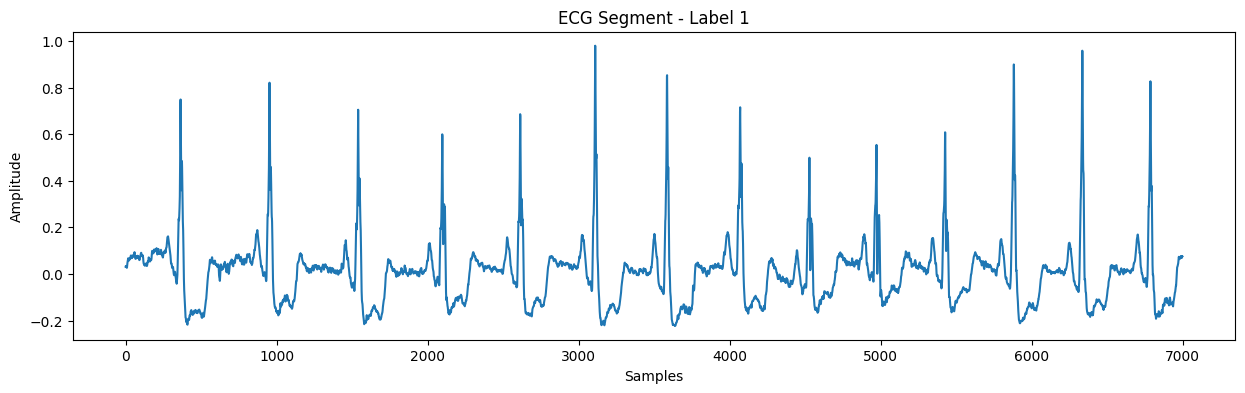

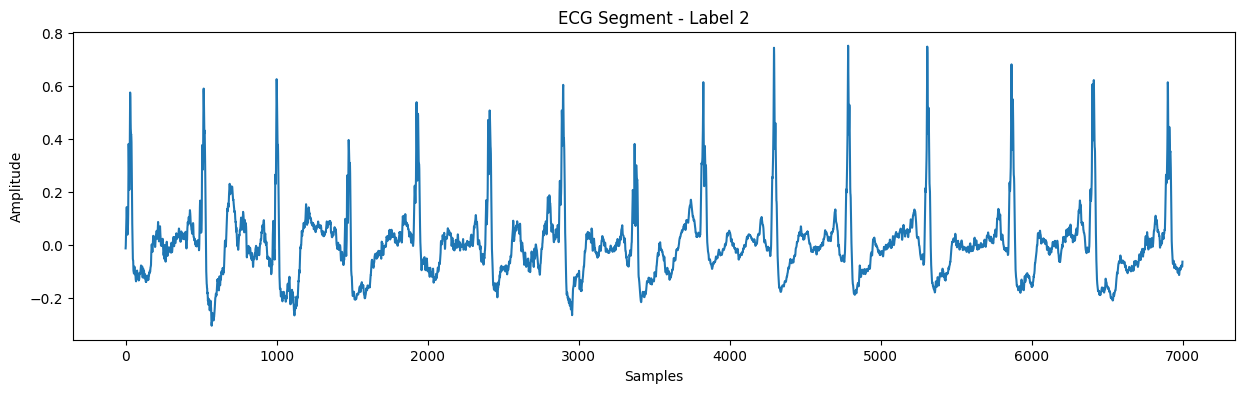

In [13]:
def plot_ecg_segment(label_value, duration_sec=10):
    idx = np.where(labels == label_value)[0]
    start = idx[0]
    end = start + duration_sec * FS

    plt.plot(ecg[start:end])
    plt.title(f"ECG Segment - Label {label_value}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

plot_ecg_segment(1)  # baseline
plot_ecg_segment(2)  # stress

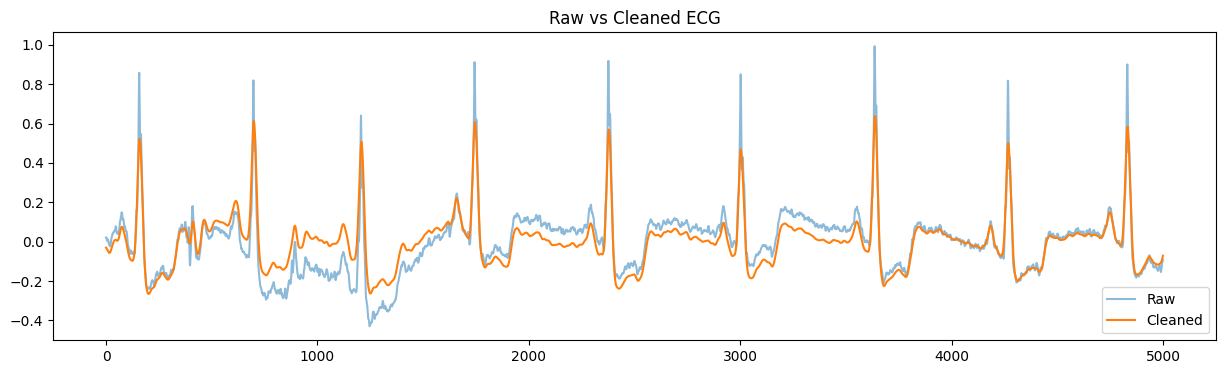

In [14]:
ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=FS)

plt.plot(ecg[:5000], label="Raw", alpha=0.5)
plt.plot(ecg_cleaned[:5000], label="Cleaned")
plt.legend()
plt.title("Raw vs Cleaned ECG")
plt.show()